In [3]:
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format
from fuzzywuzzy import process
import numpy as np
np.set_printoptions(suppress=True)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ydata_profiling import ProfileReport
import sweetviz as sv

In [5]:
!pip install flashtext

In [2]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install sweetviz

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install pandas numpy matplotlib seaborn python-docx scipy

Note: you may need to restart the kernel to use updated packages.


## sweetviz Method

In [3]:
import pandas as pd
from ydata_profiling import ProfileReport

df =  pd.read_csv("C:\\Users\\there\\OneDrive\\Desktop\\cancer_data_denmark.csv")

profile = ProfileReport(df, title="Automatic EDA Report", explorative=True)
profile.to_file("eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 38.09it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
import sweetviz as sv
import pandas as pd

df =  pd.read_csv("C:\\Users\\there\\OneDrive\\Desktop\\cancer_data_denmark.csv")

report = sv.analyze(df)
report.show_html("sweetviz_report.html")

                                             |                                             | [  0%]   00:00 ->…

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [1]:
# 2nd

In [17]:
import pandas as pd
from ydata_profiling import ProfileReport

df =  pd.read_csv("cleaned_bank_data.csv")

profile = ProfileReport(df, title="Automatic EDA Report", explorative=True)
profile.to_file("eda_report.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 26/26 [00:22<00:00,  1.14it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
import sweetviz as sv
import pandas as pd

df =  pd.read_csv("cleaned_bank_data.csv")

report = sv.analyze(df)
report.show_html("sweetviz_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Autocleaning Dataset

In [2]:
import pandas as pd
import numpy as np
import re

# -----------------------------------------------------------
# 1. SUPER-FAST TEXT NORMALIZATION
# -----------------------------------------------------------
def normalize_text(series):
    return (series.astype(str)
                  .str.lower()
                  .str.strip()
                  .str.replace(r'[^a-z0-9 ]', '', regex=True)
                  .str.replace(r'\s+', ' ', regex=True))


# -----------------------------------------------------------
# 2. FAST CATEGORY CLEANING USING PREFIX CLUSTERING
# -----------------------------------------------------------
def fast_category_clean(series, min_freq=30):
    s = normalize_text(series)

    # Get high-frequency categories → treated as "correct"
    freq = s.value_counts()
    ref = freq[freq >= min_freq].index.tolist()

    # If no stable categories found → return normalized version
    if len(ref) == 0:
        return s

    # Prefix-based correction (VERY fast)
    def correct(val):
        if len(val) < 5:
            return val
        prefix = val[:5]
        for r in ref:
            if r.startswith(prefix):
                return r
        return val

    return s.apply(correct)


# -----------------------------------------------------------
# 3. CLEAN NUMERIC COLUMNS
# -----------------------------------------------------------
def clean_numeric(series):
    s = pd.to_numeric(series, errors='coerce')

    # Fill missing with median
    s = s.fillna(s.median())

    # Outlier capping (1%–99%)
    lower = s.quantile(0.01)
    upper = s.quantile(0.99)
    s = s.clip(lower, upper)

    return s


# -----------------------------------------------------------
# 4. FULL AUTOMATIC CLEANING PIPELINE
# -----------------------------------------------------------
def ultra_fast_clean(df):
    df = df.copy()

    for col in df.columns:
        print(f"Cleaning column: {col}")

        if df[col].dtype == 'object':
            df[col] = fast_category_clean(df[col])
        else:
            df[col] = clean_numeric(df[col])

    return df


# -----------------------------------------------------------
# 5. SAVE CLEANED DATASET
# -----------------------------------------------------------
def save_cleaned(df, filename="Cleaned_Bank_Data.xlsx"):
    df.to_excel(filename, index=False)
    print(f"\nFile saved successfully → {filename}")


In [4]:
df = pd.read_csv("C:\\Users\\there\\OneDrive\\Desktop\\Bank data Project.csv")

clean_df = ultra_fast_clean(df)


Cleaning column: Customer_ID
Cleaning column: Customer_Name
Cleaning column: Age
Cleaning column: Gender
Cleaning column: Occupation
Cleaning column: Annual_Income
Cleaning column: City
Cleaning column: State
Cleaning column: Loan_Type
Cleaning column: Loan_Amount
Cleaning column: Loan_Status
Cleaning column: Credit_Score
Cleaning column: EMI_Amount
Cleaning column: Loan_Term
Cleaning column: Loan_Approval_Date
Cleaning column: Mobile_Number
Cleaning column: Bank_Branch
Cleaning column: Account_Balance
Cleaning column: Interest_Rate
Cleaning column: Loan_Repayment_Status
Cleaning column: Disbursed_Amount
Cleaning column: Branch_Manager


In [5]:
# 2nd

In [10]:
import pandas as pd
import numpy as np
from flashtext import KeywordProcessor
import re

# ----------------------------------------------------
# AUTO-GENERATE CLEANING RULES FROM EACH COLUMN
# ----------------------------------------------------
def generate_auto_rules(df):
    rules = {}

    cat_cols = df.select_dtypes(include="object").columns

    for col in cat_cols:
        print(f"🔍 Generating rules for column: {col}")

        # Normalize text temporarily
        temp = (
            df[col]
            .astype(str)
            .str.lower()
            .str.strip()
            .str.replace(r"[^a-z0-9 ]", " ", regex=True)
            .str.replace(r"\s+", " ", regex=True)
        )

        # Count values
        vc = temp.value_counts()

        # Find most common spelling
        if len(vc) == 0:
            continue

        main_value = vc.idxmax()

        # Identify rare variants (less than 1%)
        rare = vc[vc < 0.01 * len(df)].index.tolist()

        # Build mapping
        for val in rare:
            if val != main_value:
                rules[val] = main_value.title()

    return rules



# ----------------------------------------------------
# SUPER-FAST FLASH CLEAN USING GENERATED RULES
# ----------------------------------------------------
def flash_clean_auto(df, rules):
    df = df.copy()

    kp = KeywordProcessor(case_sensitive=False)
    for wrong, correct in rules.items():
        kp.add_keyword(wrong, correct)

    cat_cols = df.select_dtypes(include="object").columns

    for col in cat_cols:
        print("⚡ Cleaning Column →", col)

        df[col] = (
            df[col]
            .astype(str)
            .str.lower()
            .str.strip()
            .str.replace(r"[^a-z0-9 ]", " ", regex=True)
            .str.replace(r"\s+", " ", regex=True)
        )

        # Apply fast matching
        df[col] = df[col].apply(lambda x: kp.replace_keywords(x))

        df[col] = df[col].str.title()

    # Fill numeric columns
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(df[col].median())

    return df


In [11]:
df = pd.read_excel("C:\\Users\\there\\OneDrive\\Desktop\\FashionDataset.xlsx")

# Step A: Generate rules automatically
auto_rules = generate_auto_rules(df)

print("🔥 AUTO GENERATED RULES:")
print(auto_rules)


SyntaxError: unmatched ')' (3153169408.py, line 1)

# Main Automation project

In [1]:
import os
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from docx import Document
from docx.shared import Inches
from scipy.stats import chi2_contingency
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [13]:
# YOU ALREADY HAVE YOUR DATAFRAME:
df =  df = pd.read_csv("cleaned_bank_data.csv")
# ------------------------------------------------------------

# ------------------ REPORT CONFIG (controls size) ------------------
MAX_NUMERIC = 10
MAX_CATEGORICAL = 20
TOP_NUMNUM_PAIRS = 10
TOP_NUMCAT_PAIRS = 10
TOP_CATCAT_PAIRS = 8
MAX_CAT_CARD = 15
PLOT_DPI = 110

OUTPUT = "AUTO_EDA_HYBRID_REPORT"
os.makedirs(OUTPUT, exist_ok=True)
os.makedirs(f"{OUTPUT}/plots", exist_ok=True)
current_dt = datetime.now()
formatted_dt = current_dt.strftime("%d %B %Y, %I:%M %p")


In [14]:
# ------------------ HELPER FUNCTIONS ------------------
def eta_squared(an_series, num_series):
    df_temp = pd.concat([an_series, num_series], axis=1).dropna()
    groups = df_temp.groupby(an_series)[num_series.name]
    grand_mean = df_temp[num_series.name].mean()
    ss_between = sum([(g.count() * (g.mean() - grand_mean)**2) for _, g in groups])
    ss_total = ((df_temp[num_series.name] - grand_mean)**2).sum()
    if ss_total == 0:
        return 0.0
    return float(ss_between / ss_total)

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.size == 0:
        return 0.0
    chi2, _, _, _ = chi2_contingency(ct, correction=False)
    n = ct.sum().sum()
    if n == 0:
        return 0.0
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if (min(kcorr-1, rcorr-1) <= 0):
        return 0.0
    return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))

def save_fig(fig, path):
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")

In [15]:
# ------------------ SELECT COLUMNS ------------------
n_rows, n_cols = df.shape

num_cols_all = df.select_dtypes(include=np.number).columns.tolist()
cat_cols_all = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols_sorted = sorted(
    num_cols_all,
    key=lambda c: df[c].var() if df[c].notna().sum() > 0 else 0,
    reverse=True
)
num_cols = num_cols_sorted[:MAX_NUMERIC]

cat_candidates = [
    c for c in cat_cols_all
    if 1 < df[c].nunique() <= MAX_CAT_CARD
]
cat_cols = sorted(cat_candidates, key=lambda c: df[c].nunique())[:MAX_CATEGORICAL]

In [16]:
# ------------------ CREATE DOCUMENT ------------------
doc = Document()
doc.add_heading("Hybrid Automated EDA Report", level=1)
doc.add_paragraph("Source: cancer_data_denmark.csv")
doc.add_paragraph(f"Rows: {n_rows}   Columns: {n_cols}")
doc.add_paragraph("This report is optimized to generate 50–60 pages maximum.")

# ------------------ DATASET SUMMARY ------------------
doc = Document()
doc.add_heading("Hybrid Automated EDA Report", level=1)

doc.add_paragraph(f"Generated on: {formatted_dt}")
doc.add_paragraph("Source: cancer_data_denmark.csv")
doc.add_paragraph(f"Rows: {n_rows}   Columns: {n_cols}")


doc.add_paragraph("Missing values (top 30):")
mv = df.isnull().sum().sort_values(ascending=False).head(30)
doc.add_paragraph(str(mv.to_string()))

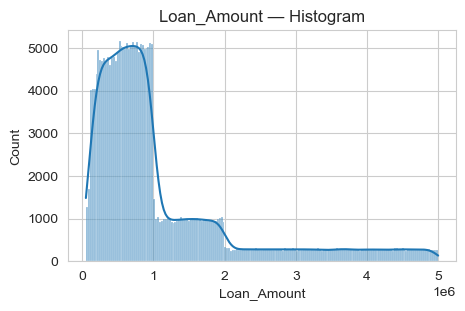

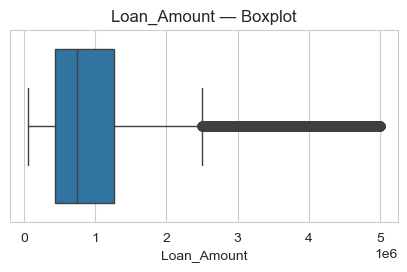

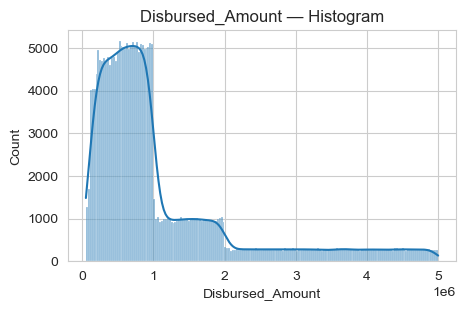

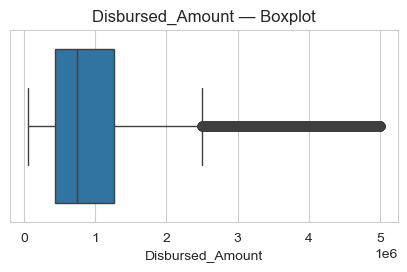

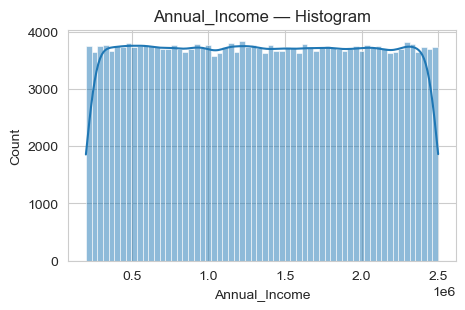

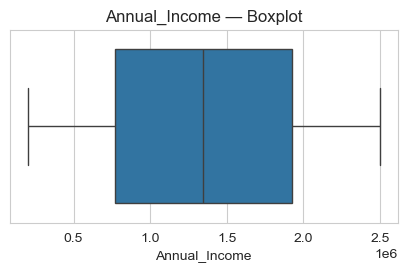

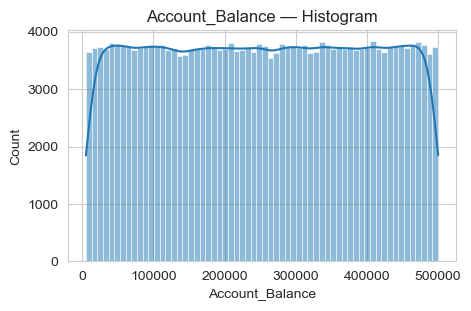

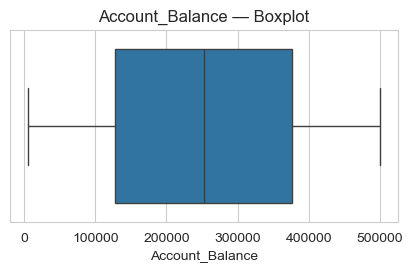

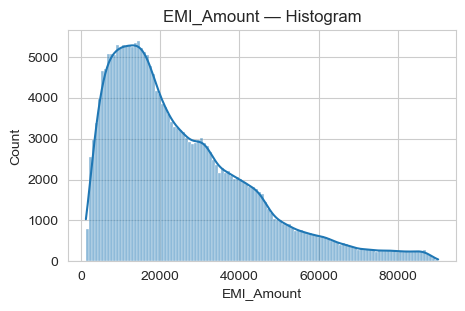

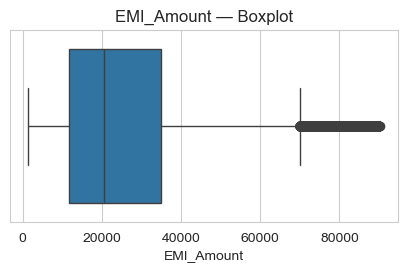

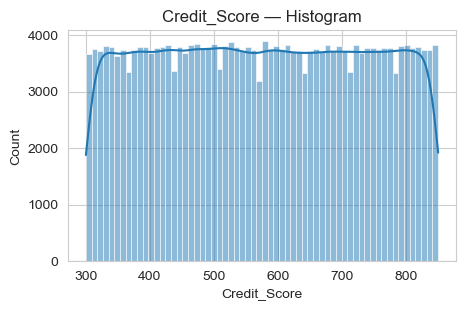

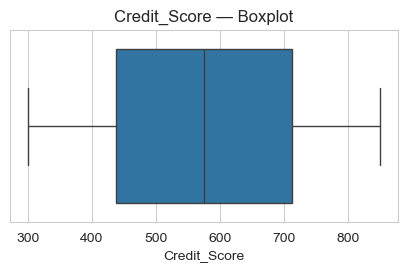

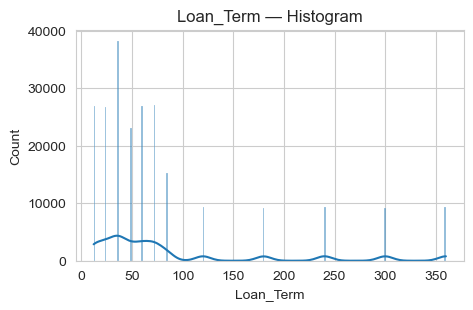

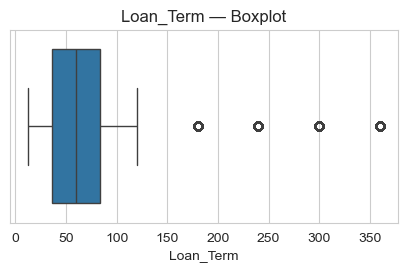

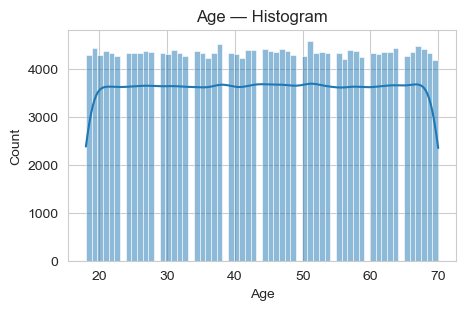

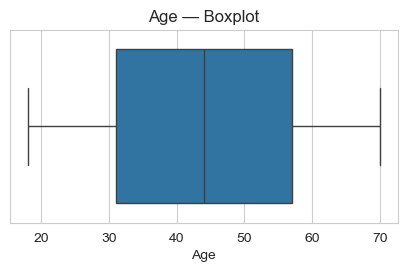

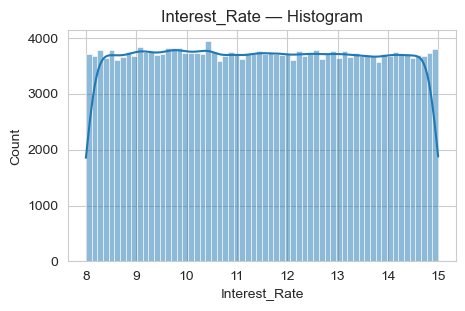

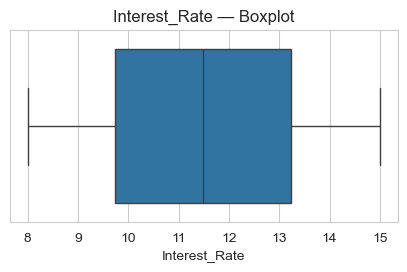

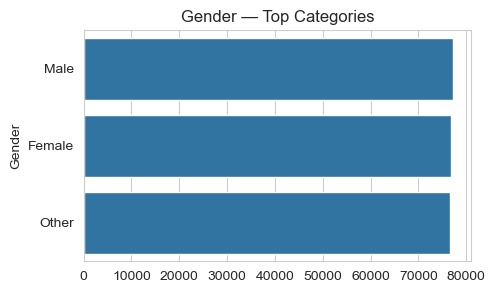

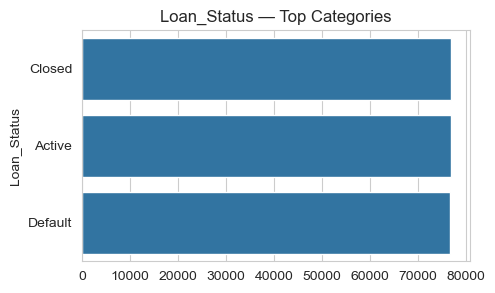

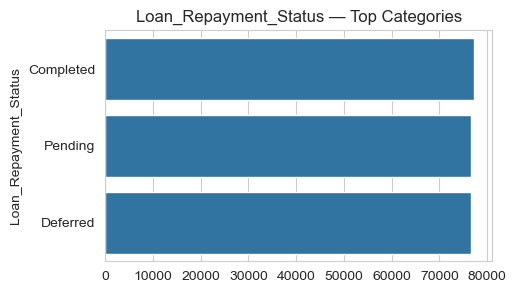

In [17]:
# ------------------ UNIVARIATE NUMERIC ------------------
doc.add_heading("2. Univariate Analysis — Numeric", level=2)

for col in num_cols:
    s = df[col].dropna()
    if s.size == 0:
        continue

    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1

    doc.add_heading(col, level=3)
    doc.add_paragraph(
        f"count={s.count()}  mean={s.mean():.2f}  median={s.median():.2f}  "
        f"std={s.std():.2f}  IQR={iqr:.2f}  min={s.min()}  max={s.max()}"
    )

    # Histogram
    fig = plt.figure(figsize=(5,3))
    sns.histplot(s, kde=True)
    plt.title(f"{col} — Histogram")
    save_fig(fig, f"{OUTPUT}/plots/{col}_hist.png")
    doc.add_picture(f"{OUTPUT}/plots/{col}_hist.png", width=Inches(5))

    # Boxplot
    fig = plt.figure(figsize=(5,2.5))
    sns.boxplot(x=s)
    plt.title(f"{col} — Boxplot")
    save_fig(fig, f"{OUTPUT}/plots/{col}_box.png")
    doc.add_picture(f"{OUTPUT}/plots/{col}_box.png", width=Inches(5))

# ------------------ UNIVARIATE CATEGORICAL ------------------
doc.add_heading("3. Univariate Analysis — Categorical", level=2)

for col in cat_cols:
    vc = df[col].astype(str).value_counts().head(12)

    doc.add_heading(col, level=3)
    doc.add_paragraph("Top categories (count):")
    doc.add_paragraph(vc.to_string())

    fig = plt.figure(figsize=(5,3))
    sns.barplot(x=vc.values, y=vc.index)
    plt.title(f"{col} — Top Categories")
    save_fig(fig, f"{OUTPUT}/plots/{col}_count.png")
    doc.add_picture(f"{OUTPUT}/plots/{col}_count.png", width=Inches(5))


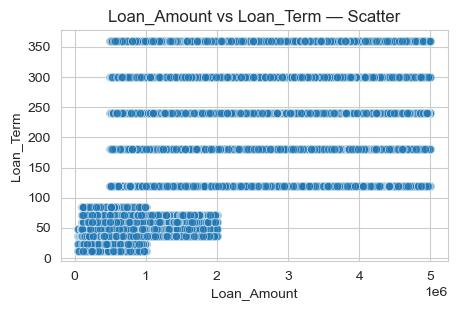

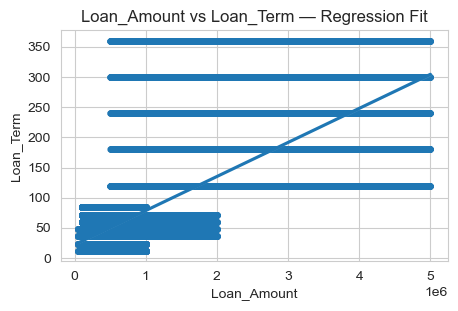

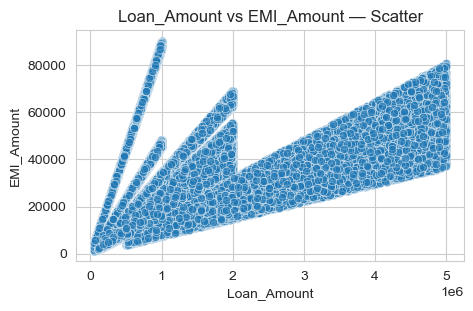

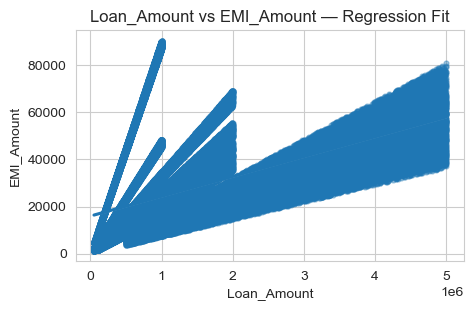

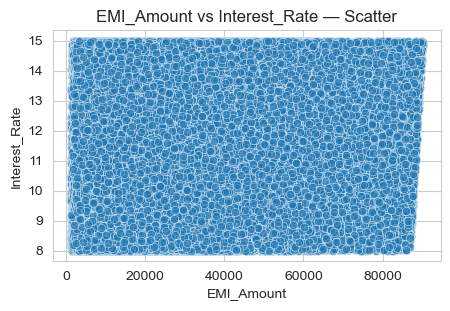

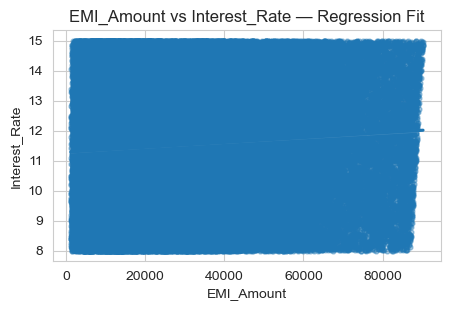

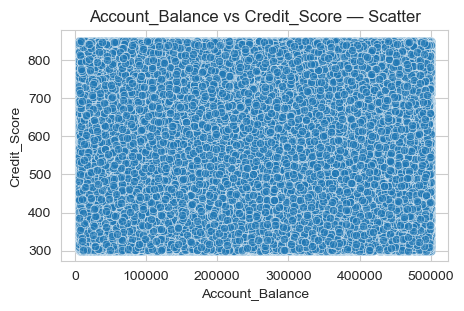

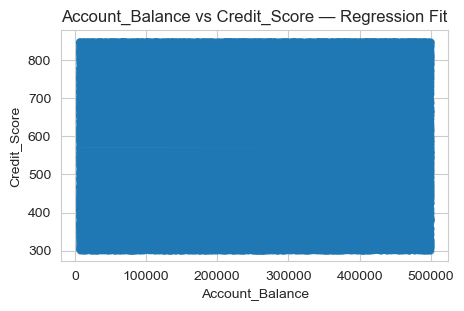

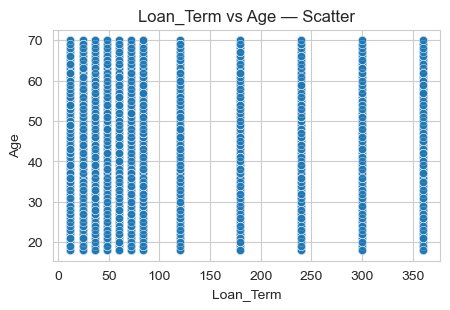

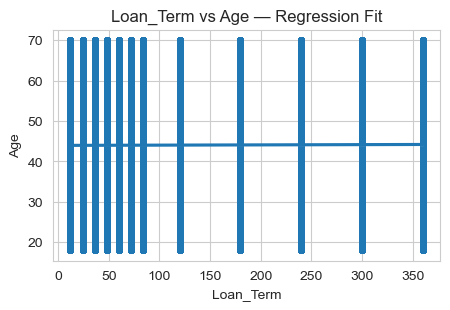

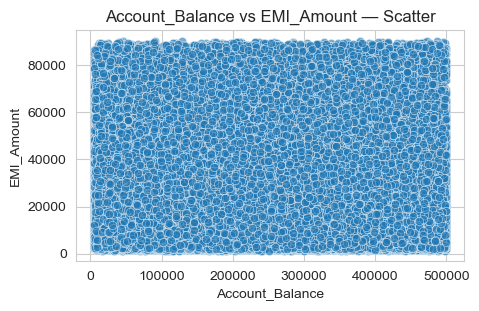

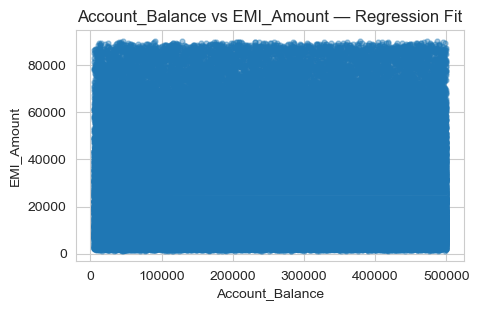

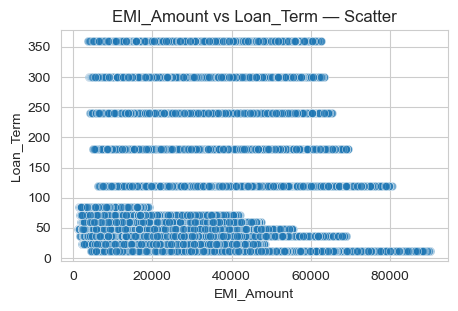

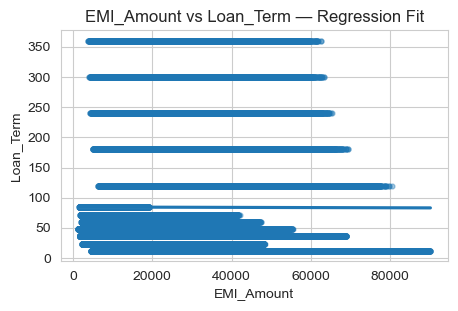

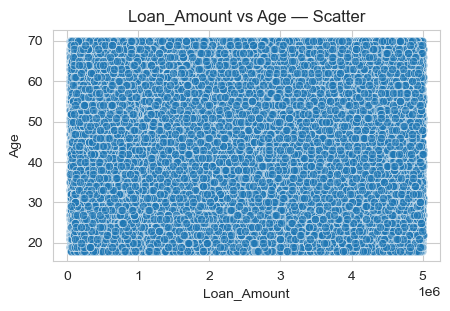

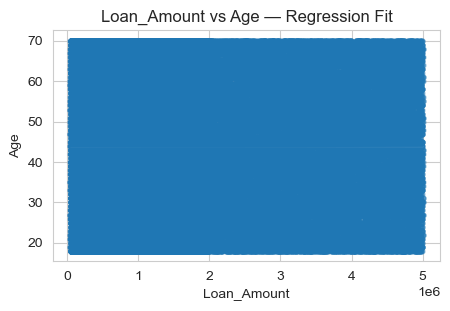

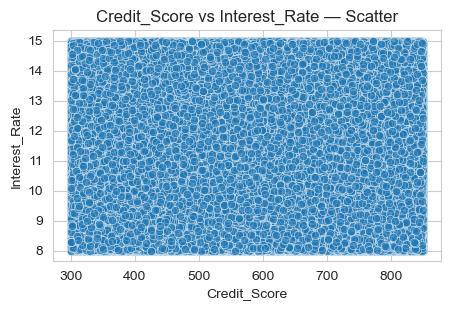

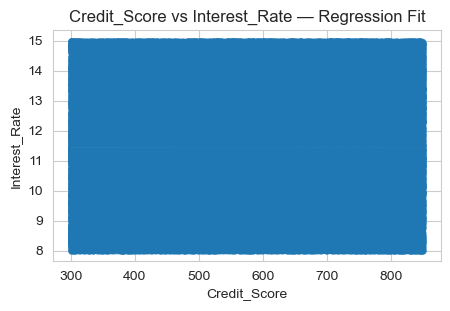

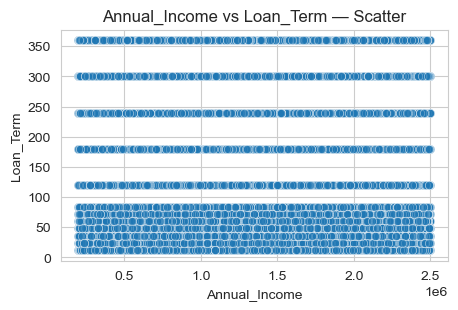

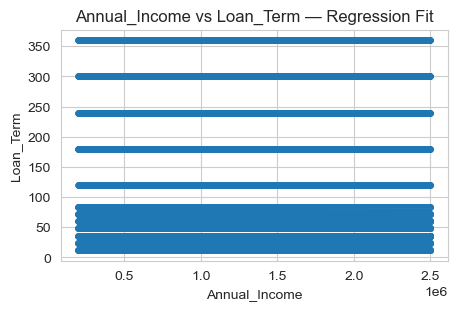

In [18]:
# ------------------ BIVARIATE: NUM–NUM (top correlated pairs) ------------------
doc.add_heading("4. Numeric vs Numeric — Top Correlations", level=2)

if len(num_cols) >= 2:
    corr = df[num_cols].corr().abs().unstack().drop_duplicates()
    corr = corr[corr < 1.0].sort_values(ascending=False)

    pairs = []
    for (a, b), val in corr.items():
        if (b, a) not in pairs:
            pairs.append((a, b, val))
    pairs = pairs[:TOP_NUMNUM_PAIRS]

    for a, b, val in pairs:

        doc.add_heading(f"{a} vs {b} (Correlation = {val:.2f})", level=3)

        # Explanation
        doc.add_paragraph(
            f"This section examines the linear relationship between '{a}' and '{b}'.\n"
            f"Correlation measures strength and direction:\n"
            f"- Positive values → direct relationship\n"
            f"- Negative values → inverse relationship\n"
            f"- Values near 0 → weak or no relationship\n"
        )

        # Scatter plot
        fig = plt.figure(figsize=(5,3))
        sns.scatterplot(x=df[a], y=df[b], alpha=0.6)
        plt.title(f"{a} vs {b} — Scatter")
        sp = f"{OUTPUT}/plots/{a}_{b}_scatter.png"
        save_fig(fig, sp)
        doc.add_paragraph("Scatterplot:")
        doc.add_picture(sp, width=Inches(5))

        # Regression
        fig = plt.figure(figsize=(5,3))
        sns.regplot(x=df[a], y=df[b], scatter_kws={'s':12, 'alpha':0.4})
        plt.title(f"{a} vs {b} — Regression Fit")
        rp = f"{OUTPUT}/plots/{a}_{b}_reg.png"
        save_fig(fig, rp)
        doc.add_paragraph("Regression Line Fit:")
        doc.add_picture(rp, width=Inches(5))

        # Interpretation
        doc.add_paragraph(
            f"Insight:\n"
            f"- The correlation coefficient is {val:.2f}.\n"
            f"- Higher absolute correlation indicates stronger linear association.\n"
            f"- Regression line helps visualize the trend direction."
        )


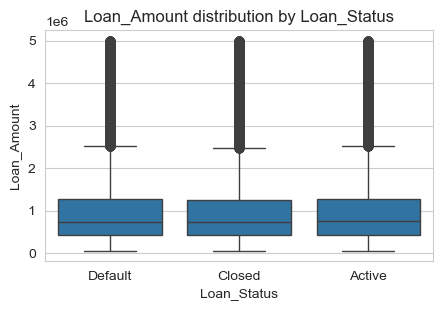

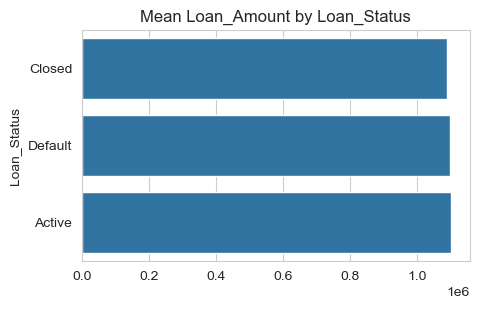

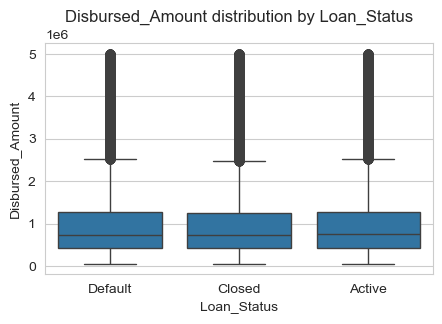

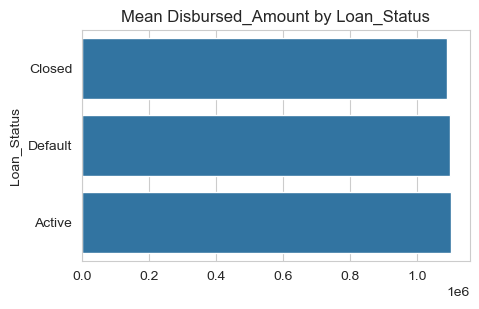

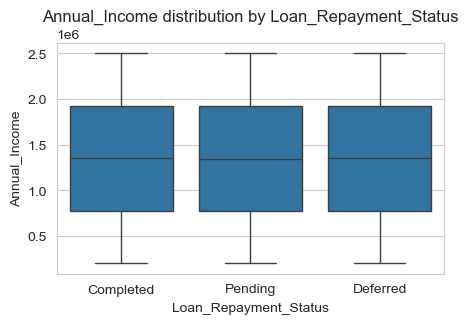

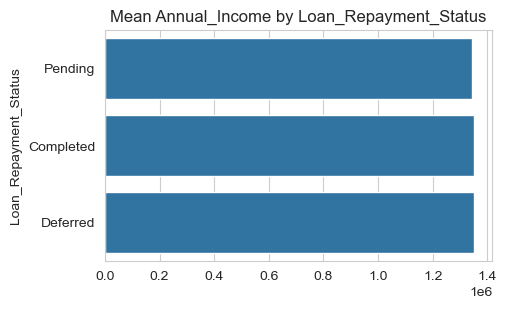

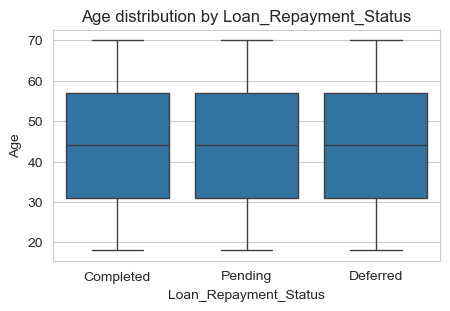

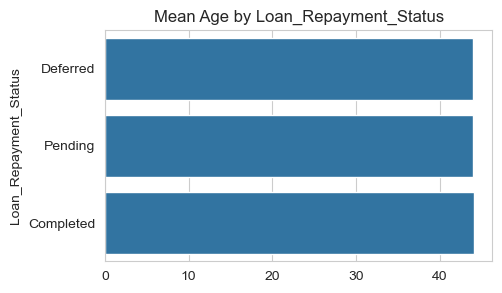

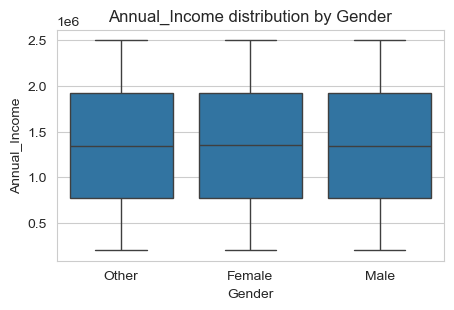

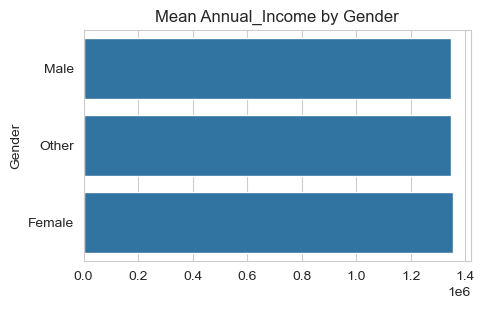

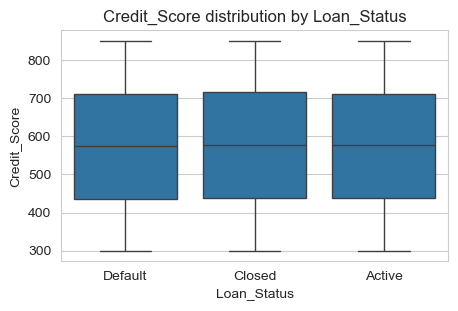

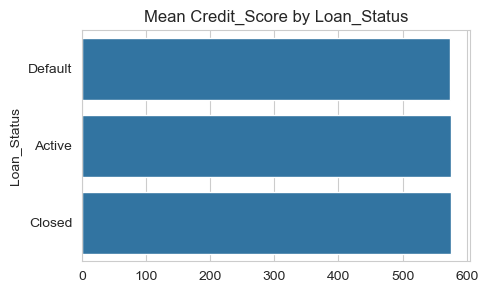

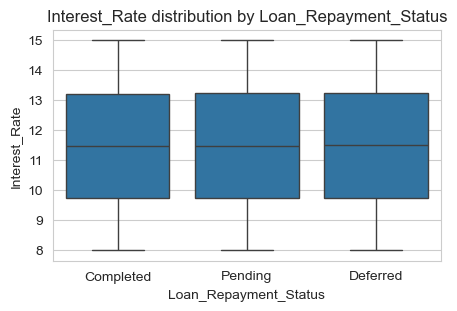

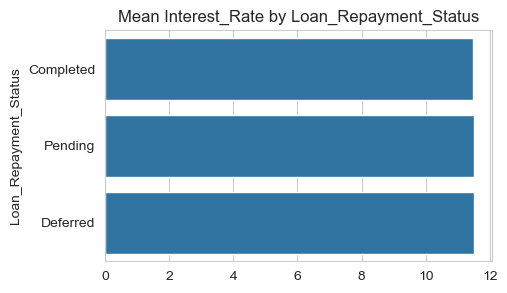

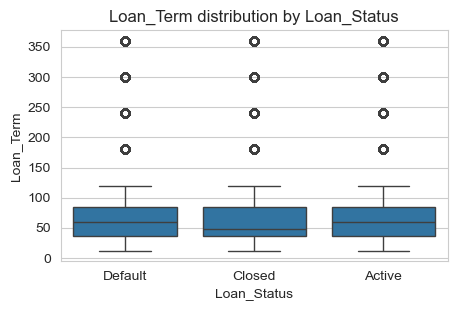

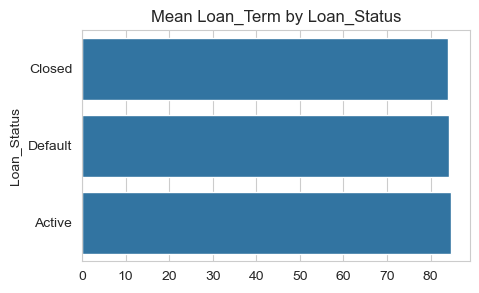

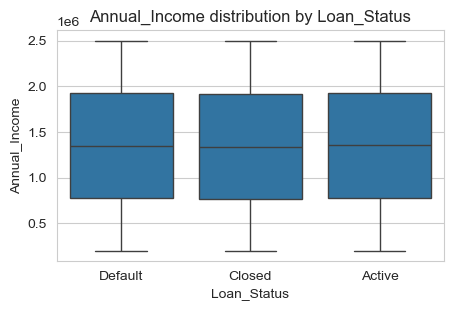

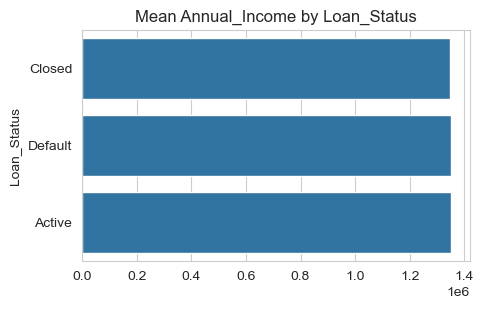

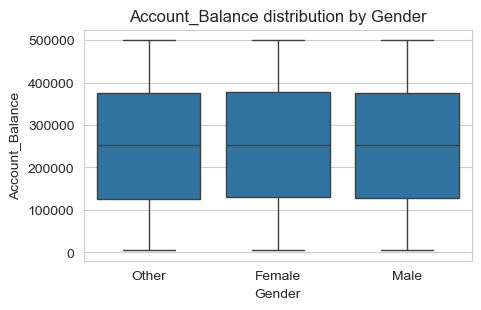

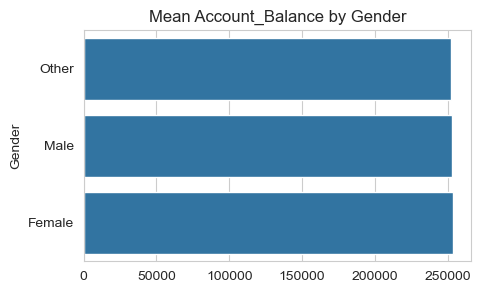

In [19]:
# ------------------ BIVARIATE: NUM–CAT (Top Eta² influence) ------------------
doc.add_heading("5. Numeric vs Categorical — Most Influential", level=2)

numcat_scores = []
for num in num_cols:
    for cat in cat_cols:
        try:
            score = eta_squared(df[cat].astype(str), df[num])
        except:
            score = 0
        numcat_scores.append((num, cat, score))

numcat_scores = sorted(numcat_scores, key=lambda x: x[2], reverse=True)[:TOP_NUMCAT_PAIRS]

for num, cat, score in numcat_scores:

    # Section title
    doc.add_heading(f"{num} by {cat} (Eta² = {score:.3f})", level=3)

    # Explanation
    doc.add_paragraph(
        f"This section compares the numeric variable '{num}' "
        f"across the categories of '{cat}'.\n"
        f"A higher Eta² value indicates that the categorical variable "
        f"'{cat}' explains more variation in '{num}'."
    )

    # Summary Table
    grp = df.groupby(cat)[num].agg(['count', 'mean', 'median', 'std']).round(2)
    doc.add_paragraph("Group Statistics:")
    doc.add_paragraph(grp.to_string())

    # Boxplot
    fig = plt.figure(figsize=(5,3))
    sns.boxplot(x=df[cat].astype(str), y=df[num])
    plt.title(f"{num} distribution by {cat}")
    path1 = f"{OUTPUT}/plots/{num}_{cat}_box.png"
    save_fig(fig, path1)
    doc.add_paragraph("Plot:")
    doc.add_picture(path1, width=Inches(5))

    # Mean bar chart
    means = df.groupby(df[cat].astype(str))[num].mean().sort_values()
    fig = plt.figure(figsize=(5,3))
    sns.barplot(x=means.values, y=means.index)
    plt.title(f"Mean {num} by {cat}")
    path2 = f"{OUTPUT}/plots/{num}_{cat}_mean.png"
    save_fig(fig, path2)
    doc.add_picture(path2, width=Inches(5))

    # Interpretation
    doc.add_paragraph(
        f"Interpretation:\n"
        f"- The variable '{num}' shows differences across levels of '{cat}'.\n"
        f"- Categories with higher means indicate stronger association.\n"
        f"- Eta² = {score:.3f} (0 = no effect, 1 = strong effect)."
    )



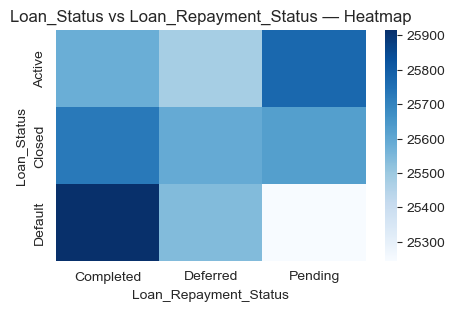

<Figure size 500x300 with 0 Axes>

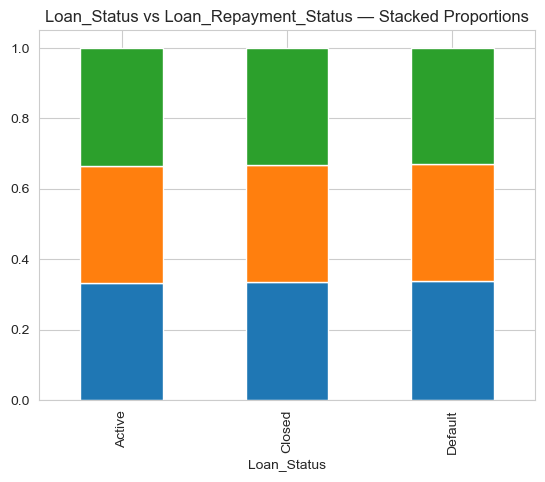

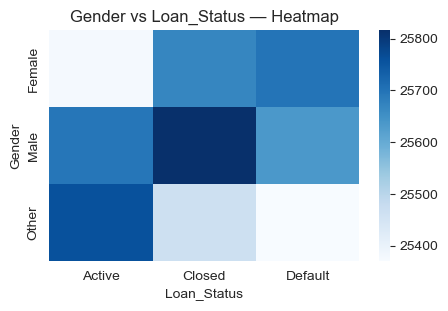

<Figure size 500x300 with 0 Axes>

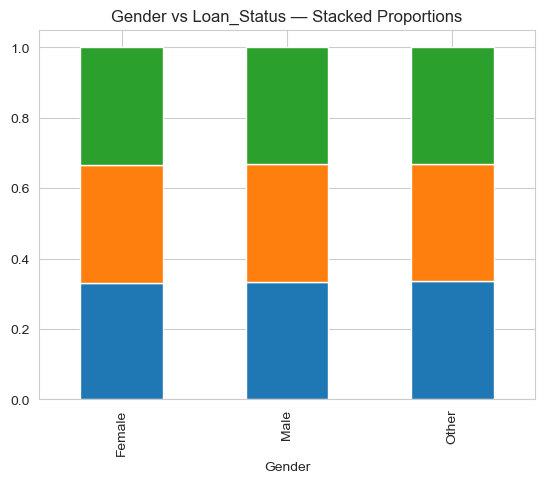

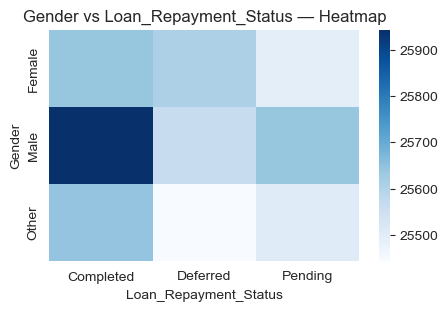

<Figure size 500x300 with 0 Axes>

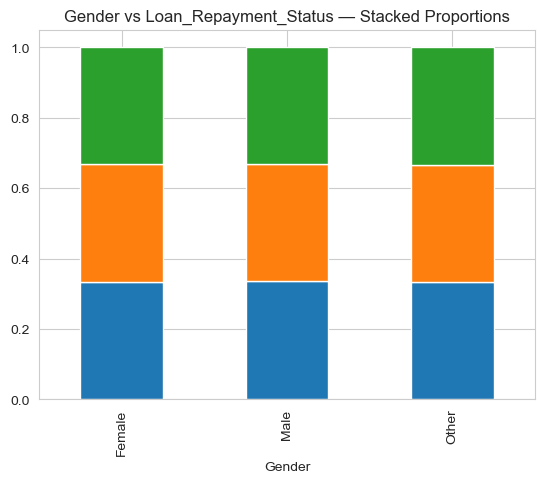

In [20]:
# ------------------ BIVARIATE: CAT–CAT (Top associations) ------------------
doc.add_heading("6. Categorical vs Categorical — Top Associations", level=2)

catcat_scores = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        c1, c2 = cat_cols[i], cat_cols[j]
        try:
            v = cramers_v(df[c1].astype(str), df[c2].astype(str))
        except:
            v = 0
        catcat_scores.append((c1, c2, v))

catcat_scores = sorted(catcat_scores, key=lambda x: x[2], reverse=True)[:TOP_CATCAT_PAIRS]

for c1, c2, v in catcat_scores:

    doc.add_heading(f"{c1} vs {c2} (Cramer's V = {v:.3f})", level=3)

    doc.add_paragraph(
        f"This section evaluates the association between two categorical variables:\n"
        f"- Cramer's V ranges from 0 to 1\n"
        f"- 0 = No association\n"
        f"- 1 = Perfect association\n"
        f"A higher value indicates stronger interaction between '{c1}' and '{c2}'."
    )

    # Crosstab
    ct = pd.crosstab(df[c1].astype(str), df[c2].astype(str))
    doc.add_paragraph("Crosstab Summary:")
    doc.add_paragraph(str(ct))

    # Heatmap
    fig = plt.figure(figsize=(5,3))
    sns.heatmap(ct, cmap="Blues")
    plt.title(f"{c1} vs {c2} — Heatmap")
    hp = f"{OUTPUT}/plots/{c1}_{c2}_heat.png"
    save_fig(fig, hp)
    doc.add_paragraph("Heatmap:")
    doc.add_picture(hp, width=Inches(5))

    # Stacked bar
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    fig = plt.figure(figsize=(5,3))
    ct_norm.plot(kind="bar", stacked=True, legend=False)
    plt.title(f"{c1} vs {c2} — Stacked Proportions")
    sb = f"{OUTPUT}/plots/{c1}_{c2}_stack.png"
    save_fig(fig, sb)
    doc.add_paragraph("Stacked Bar Chart:")
    doc.add_picture(sb, width=Inches(5))

    # Interpretation
    doc.add_paragraph(
        f"Insight:\n"
        f"- Cramer's V = {v:.3f} indicates the strength of association.\n"
        f"- The heatmap helps identify concentration patterns.\n"
        f"- Stacked bars show proportional distribution of categories."
    )


In [21]:

# ------------------ INSIGHTS ------------------
doc.add_heading("7. Insights & Conclusion", level=2)
doc.add_paragraph("This hybrid report highlights the most impactful relationships while remaining compact (50–60 pages).")
doc.add_paragraph("Use this report as a foundation for deeper modeling or domain-level interpretation.")

safe_dt = current_dt.strftime("%Y%m%d_%H%M")
doc.save(f"{OUTPUT}/Bankdata_finalautocleaning_EDA_Report_{safe_dt}.docx")

print("Report saved to:", f"{OUTPUT}/Bankdata_finalautocleaning_EDA_Report.docx")

Report saved to: AUTO_EDA_HYBRID_REPORT/Bankdata_finalautocleaning_EDA_Report.docx


In [ ]:
import os
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from docx import Document
from docx.shared import Inches
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# ------------------------------------------------------------
# YOU ALREADY HAVE YOUR DATAFRAME:
df = pd.read_csv("C:\\Users\\there\\OneDrive\\Desktop\\cancer_data_denmark.csv")
# ------------------------------------------------------------

# ------------------ REPORT CONFIG (controls size) ------------------
MAX_NUMERIC = 8
MAX_CATEGORICAL = 10
TOP_NUMNUM_PAIRS = 6
TOP_NUMCAT_PAIRS = 6
TOP_CATCAT_PAIRS = 4
MAX_CAT_CARD = 12
PLOT_DPI = 110

OUTPUT = "AUTO_EDA_HYBRID_REPORT"
os.makedirs(OUTPUT, exist_ok=True)
os.makedirs(f"{OUTPUT}/plots", exist_ok=True)

# ------------------ HELPER FUNCTIONS ------------------
def eta_squared(an_series, num_series):
    df_temp = pd.concat([an_series, num_series], axis=1).dropna()
    groups = df_temp.groupby(an_series)[num_series.name]
    grand_mean = df_temp[num_series.name].mean()
    ss_between = sum([(g.count() * (g.mean() - grand_mean)**2) for _, g in groups])
    ss_total = ((df_temp[num_series.name] - grand_mean)**2).sum()
    if ss_total == 0:
        return 0.0
    return float(ss_between / ss_total)

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.size == 0:
        return 0.0
    chi2, _, _, _ = chi2_contingency(ct, correction=False)
    n = ct.sum().sum()
    if n == 0:
        return 0.0
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if (min(kcorr-1, rcorr-1) <= 0):
        return 0.0
    return np.sqrt(phi2corr / min(kcorr-1, rcorr-1))

def save_fig(fig, path):
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.close(fig)

# ------------------ SELECT COLUMNS ------------------
n_rows, n_cols = df.shape

num_cols_all = df.select_dtypes(include=np.number).columns.tolist()
cat_cols_all = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols_sorted = sorted(
    num_cols_all,
    key=lambda c: df[c].var() if df[c].notna().sum() > 0 else 0,
    reverse=True
)
num_cols = num_cols_sorted[:MAX_NUMERIC]

cat_candidates = [
    c for c in cat_cols_all
    if 1 < df[c].nunique() <= MAX_CAT_CARD
]
cat_cols = sorted(cat_candidates, key=lambda c: df[c].nunique())[:MAX_CATEGORICAL]

# ------------------ CREATE DOCUMENT ------------------
doc = Document()
doc.add_heading("Hybrid Automated EDA Report", level=1)
doc.add_paragraph("Source: cancer_data_denmark.csv")
doc.add_paragraph(f"Rows: {n_rows}   Columns: {n_cols}")
doc.add_paragraph("This report is optimized to generate 50–60 pages maximum.")

# ------------------ DATASET SUMMARY ------------------
doc.add_heading("1. Dataset Summary", level=2)
doc.add_paragraph(f"Numeric columns used ({len(num_cols)}): {num_cols}")
doc.add_paragraph(f"Categorical columns used ({len(cat_cols)}): {cat_cols}")

doc.add_paragraph("Missing values (top 10):")
mv = df.isnull().sum().sort_values(ascending=False).head(10)
doc.add_paragraph(str(mv.to_string()))

# ------------------ UNIVARIATE NUMERIC ------------------
doc.add_heading("2. Univariate Analysis — Numeric", level=2)

for col in num_cols:
    s = df[col].dropna()
    if s.size == 0:
        continue

    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1

    doc.add_heading(col, level=3)
    doc.add_paragraph(
        f"count={s.count()}  mean={s.mean():.2f}  median={s.median():.2f}  "
        f"std={s.std():.2f}  IQR={iqr:.2f}  min={s.min()}  max={s.max()}"
    )

    # Histogram
    fig = plt.figure(figsize=(5,3))
    sns.histplot(s, kde=True)
    plt.title(f"{col} — Histogram")
    save_fig(fig, f"{OUTPUT}/plots/{col}_hist.png")
    doc.add_picture(f"{OUTPUT}/plots/{col}_hist.png", width=Inches(5))

    # Boxplot
    fig = plt.figure(figsize=(5,2.5))
    sns.boxplot(x=s)
    plt.title(f"{col} — Boxplot")
    save_fig(fig, f"{OUTPUT}/plots/{col}_box.png")
    doc.add_picture(f"{OUTPUT}/plots/{col}_box.png", width=Inches(5))

# ------------------ UNIVARIATE CATEGORICAL ------------------
doc.add_heading("3. Univariate Analysis — Categorical", level=2)

for col in cat_cols:
    vc = df[col].astype(str).value_counts().head(12)

    doc.add_heading(col, level=3)
    doc.add_paragraph("Top categories (count):")
    doc.add_paragraph(vc.to_string())

    fig = plt.figure(figsize=(5,3))
    sns.barplot(x=vc.values, y=vc.index)
    plt.title(f"{col} — Top Categories")
    save_fig(fig, f"{OUTPUT}/plots/{col}_count.png")
    doc.add_picture(f"{OUTPUT}/plots/{col}_count.png", width=Inches(5))

# ------------------ BIVARIATE: NUM–NUM (top correlated pairs) ------------------
doc.add_heading("4. Numeric vs Numeric — Top Correlations", level=2)

if len(num_cols) >= 2:
    corr = df[num_cols].corr().abs().unstack().drop_duplicates()
    corr = corr[corr < 1.0].sort_values(ascending=False)

    pairs = []
    for (a, b), val in corr.items():
        if (b, a) not in pairs:
            pairs.append((a, b, val))
    pairs = pairs[:TOP_NUMNUM_PAIRS]

    for a, b, val in pairs:

        doc.add_heading(f"{a} vs {b} (Correlation = {val:.2f})", level=3)

        # Explanation
        doc.add_paragraph(
            f"This section examines the linear relationship between '{a}' and '{b}'.\n"
            f"Correlation measures strength and direction:\n"
            f"- Positive values → direct relationship\n"
            f"- Negative values → inverse relationship\n"
            f"- Values near 0 → weak or no relationship\n"
        )

        # Scatter plot
        fig = plt.figure(figsize=(5,3))
        sns.scatterplot(x=df[a], y=df[b], alpha=0.6)
        plt.title(f"{a} vs {b} — Scatter")
        sp = f"{OUTPUT}/plots/{a}_{b}_scatter.png"
        save_fig(fig, sp)
        doc.add_paragraph("Scatterplot:")
        doc.add_picture(sp, width=Inches(5))

        # Regression
        fig = plt.figure(figsize=(5,3))
        sns.regplot(x=df[a], y=df[b], scatter_kws={'s':12, 'alpha':0.4})
        plt.title(f"{a} vs {b} — Regression Fit")
        rp = f"{OUTPUT}/plots/{a}_{b}_reg.png"
        save_fig(fig, rp)
        doc.add_paragraph("Regression Line Fit:")
        doc.add_picture(rp, width=Inches(5))

        # Interpretation
    doc.add_paragraph(
            f"Insight:\n"
            f"- The correlation coefficient is {val:.2f}.\n"
            f"- Higher absolute correlation indicates stronger linear association.\n"
            f"- Regression line helps visualize the trend direction."
        )

# ------------------ BIVARIATE: NUM–CAT (Top Eta² influence) ------------------
doc.add_heading("5. Numeric vs Categorical — Most Influential", level=2)

numcat_scores = []
for num in num_cols:
    for cat in cat_cols:
        try:
            score = eta_squared(df[cat].astype(str), df[num])
        except:
            score = 0
        numcat_scores.append((num, cat, score))

numcat_scores = sorted(numcat_scores, key=lambda x: x[2], reverse=True)[:TOP_NUMCAT_PAIRS]

for num, cat, score in numcat_scores:

    # Section title
    doc.add_heading(f"{num} by {cat} (Eta² = {score:.3f})", level=3)

    # Explanation
    doc.add_paragraph(
        f"This section compares the numeric variable '{num}' "
        f"across the categories of '{cat}'.\n"
        f"A higher Eta² value indicates that the categorical variable "
        f"'{cat}' explains more variation in '{num}'."
    )

    # Summary Table
    grp = df.groupby(cat)[num].agg(['count', 'mean', 'median', 'std']).round(2)
    doc.add_paragraph("Group Statistics:")
    doc.add_paragraph(grp.to_string())

    # Boxplot
    fig = plt.figure(figsize=(5,3))
    sns.boxplot(x=df[cat].astype(str), y=df[num])
    plt.title(f"{num} distribution by {cat}")
    path1 = f"{OUTPUT}/plots/{num}_{cat}_box.png"
    save_fig(fig, path1)
    doc.add_paragraph("Plot:")
    doc.add_picture(path1, width=Inches(5))

    # Mean bar chart
    means = df.groupby(df[cat].astype(str))[num].mean().sort_values()
    fig = plt.figure(figsize=(5,3))
    sns.barplot(x=means.values, y=means.index)
    plt.title(f"Mean {num} by {cat}")
    path2 = f"{OUTPUT}/plots/{num}_{cat}_mean.png"
    save_fig(fig, path2)
    doc.add_picture(path2, width=Inches(5))

    # Interpretation
    doc.add_paragraph(
        f"Interpretation:\n"
        f"- The variable '{num}' shows differences across levels of '{cat}'.\n"
        f"- Categories with higher means indicate stronger association.\n"
        f"- Eta² = {score:.3f} (0 = no effect, 1 = strong effect)."
    )


# ------------------ BIVARIATE: CAT–CAT (Top associations) ------------------
doc.add_heading("6. Categorical vs Categorical — Top Associations", level=2)

catcat_scores = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        c1, c2 = cat_cols[i], cat_cols[j]
        try:
            v = cramers_v(df[c1].astype(str), df[c2].astype(str))
        except:
            v = 0
        catcat_scores.append((c1, c2, v))

catcat_scores = sorted(catcat_scores, key=lambda x: x[2], reverse=True)[:TOP_CATCAT_PAIRS]

for c1, c2, v in catcat_scores:

    doc.add_heading(f"{c1} vs {c2} (Cramer's V = {v:.3f})", level=3)

    doc.add_paragraph(
        f"This section evaluates the association between two categorical variables:\n"
        f"- Cramer's V ranges from 0 to 1\n"
        f"- 0 = No association\n"
        f"- 1 = Perfect association\n"
        f"A higher value indicates stronger interaction between '{c1}' and '{c2}'."
    )

    # Crosstab
    ct = pd.crosstab(df[c1].astype(str), df[c2].astype(str))
    doc.add_paragraph("Crosstab Summary:")
    doc.add_paragraph(str(ct))

    # Heatmap
    fig = plt.figure(figsize=(5,3))
    sns.heatmap(ct, cmap="Blues")
    plt.title(f"{c1} vs {c2} — Heatmap")
    hp = f"{OUTPUT}/plots/{c1}_{c2}_heat.png"
    save_fig(fig, hp)
    doc.add_paragraph("Heatmap:")
    doc.add_picture(hp, width=Inches(5))

    # Stacked bar
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    fig = plt.figure(figsize=(5,3))
    ct_norm.plot(kind="bar", stacked=True, legend=False)
    plt.title(f"{c1} vs {c2} — Stacked Proportions")
    sb = f"{OUTPUT}/plots/{c1}_{c2}_stack.png"
    save_fig(fig, sb)
    doc.add_paragraph("Stacked Bar Chart:")
    doc.add_picture(sb, width=Inches(5))

    # Interpretation
    doc.add_paragraph(
        f"Insight:\n"
        f"- Cramer's V = {v:.3f} indicates the strength of association.\n"
        f"- The heatmap helps identify concentration patterns.\n"
        f"- Stacked bars show proportional distribution of categories."
    )


# ------------------ INSIGHTS ------------------
doc.add_heading("7. Insights & Conclusion", level=2)
doc.add_paragraph("This hybrid report highlights the most impactful relationships while remaining compact (50–60 pages).")
doc.add_paragraph("Use this report as a foundation for deeper modeling or domain-level interpretation.")

doc.save(f"{OUTPUT}/cancerHybrid_EDA_Report.docx")
print("Report saved to:", f"{OUTPUT}/cancerHybrid_EDA_Report.docx")


# 2 Automation project

In [5]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from docx import Document
from docx.shared import Inches
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

In [14]:
# PERFORMANCE SETTINGS
# ------------------------------------------------------------
MAX_NUMERIC = 6            # fewer numeric columns -> speed
MAX_CATEGORICAL = 8
TOP_NUMNUM_PAIRS = 4
TOP_NUMCAT_PAIRS = 4
TOP_CATCAT_PAIRS = 3
PLOT_DPI = 80              # faster rendering
IMG_W = 4.5                # reduce image size

OUTPUT = "FAST_AUTO_EDA"
os.makedirs(OUTPUT, exist_ok=True)
os.makedirs(f"{OUTPUT}/plots", exist_ok=True)

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------
def eta_squared(cat, num):
    df_temp = pd.concat([cat, num], axis=1).dropna()
    groups = df_temp.groupby(cat)[num.name]
    grand_mean = df_temp[num.name].mean()
    ss_between = sum([(g.count() * (g.mean() - grand_mean)**2) for _, g in groups])
    ss_total = ((df_temp[num.name] - grand_mean)**2).sum()
    return ss_between / ss_total if ss_total > 0 else 0.0

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.size == 0:
        return 0.0
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

def save_fig(path):
    plt.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.close()

In [15]:
# ------------------------------------------------------------
# COLUMN SELECTION (FAST)
# ------------------------------------------------------------
num_cols = df.select_dtypes(include=np.number).columns[:MAX_NUMERIC]
cat_cols = df.select_dtypes(include=["object","category"]).columns[:MAX_CATEGORICAL]

# ------------------------------------------------------------
# WORD DOCUMENT SETUP
# ------------------------------------------------------------
doc = Document()
doc.add_heading("Fast Automated EDA Report (Optimized)", level=1)
doc.add_paragraph("Source: cancer_data_denmark.csv")
doc.add_paragraph(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")

# ------------------------------------------------------------
# UNIVARIATE NUMERIC
# ------------------------------------------------------------
doc.add_heading("1. Univariate Analysis — Numeric", level=2)

for col in num_cols:
    s = df[col]

    doc.add_heading(col, level=3)
    doc.add_paragraph(str(s.describe()))

    plt.figure(figsize=(IMG_W,3))
    plt.hist(s, bins=20)
    plt.title(col)
    path = f"{OUTPUT}/plots/{col}_hist.png"
    save_fig(path)
    doc.add_picture(path, width=Inches(IMG_W))

# ------------------------------------------------------------
# UNIVARIATE CATEGORICAL
# ------------------------------------------------------------
doc.add_heading("2. Univariate Analysis — Categorical", level=2)

for col in cat_cols:
    vc = df[col].value_counts().head(10)

    doc.add_heading(col, level=3)
    doc.add_paragraph(vc.to_string())

    plt.figure(figsize=(IMG_W,3))
    plt.barh(vc.index, vc.values)
    plt.title(col)
    path = f"{OUTPUT}/plots/{col}_cat.png"
    save_fig(path)
    doc.add_picture(path, width=Inches(IMG_W))


In [ ]:
# BIVARIATE NUM-NUM (FAST)
# ------------------------------------------------------------
doc.add_heading("3. Numeric vs Numeric — Correlation", level=2)

corr = df[num_cols].corr().abs()
pairs = (
    corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(TOP_NUMNUM_PAIRS)
)

for (a, b), val in pairs.items():
    doc.add_heading(f"{a} vs {b} (corr={val:.2f})", level=3)

    plt.figure(figsize=(IMG_W,3))
    plt.scatter(df[a], df[b], s=10)
    plt.title(f"{a} vs {b}")
    path = f"{OUTPUT}/plots/{a}_{b}.png"
    save_fig(path)
    doc.add_picture(path, width=Inches(IMG_W))

# ------------------------------------------------------------
# NUM-CAT (FAST)
# ------------------------------------------------------------
doc.add_heading("4. Numeric vs Categorical", level=2)

scores = []
for num in num_cols:
    for cat in cat_cols:
        scores.append((num, cat, eta_squared(df[cat], df[num])))

scores = sorted(scores, key=lambda x: x[2], reverse=True)[:TOP_NUMCAT_PAIRS]

for num, cat, s in scores:
    doc.add_heading(f"{num} by {cat} (Eta²={s:.3f})", level=3)

    grp = df.groupby(cat)[num].mean()

    plt.figure(figsize=(IMG_W,3))
    plt.barh(grp.index.astype(str), grp.values)
    plt.title(f"{num} by {cat}")
    path = f"{OUTPUT}/plots/{num}_{cat}.png"
    save_fig(path)
    doc.add_picture(path, width=Inches(IMG_W))

# --------------------------------

In [ ]:
# ------------------------------------------------------------
# CAT–CAT (FAST)
# ------------------------------------------------------------
doc.add_heading("5. Categorical vs Categorical", level=2)

cat_pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        c1, c2 = cat_cols[i], cat_cols[j]
        cat_pairs.append((c1, c2, cramers_v(df[c1], df[c2])))

cat_pairs = sorted(cat_pairs, key=lambda x: x[2], reverse=True)[:TOP_CATCAT_PAIRS]

for c1, c2, val in cat_pairs:
    ct = pd.crosstab(df[c1], df[c2])

    doc.add_heading(f"{c1} vs {c2} (Cramer's V={val:.2f})", level=3)
    doc.add_paragraph(str(ct))

# ------------------------------------------------------------

In [ ]:
# END REPORT
# ------------------------------------------------------------
doc.save(f"{OUTPUT}/FAST_EDA_Report.docx")
print("Report saved:", f"{OUTPUT}/FAST_EDA_Report.docx")

In [ ]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from docx import Document
from docx.shared import Inches
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# ------------------------------------------------------------
# LOAD DATA
df = pd.read_csv("C:\\Users\\there\\OneDrive\\Desktop\\cancer_data_denmark.csv")
# ------------------------------------------------------------

# ------------------------------------------------------------
# AUTO DATA CLEANING FUNCTION (FAST)
# ------------------------------------------------------------
def auto_clean(df):
    df = df.copy()
    
    # 1. Drop duplicates
    df.drop_duplicates(inplace=True)

    # 2. Remove constant columns
    constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
    df.drop(columns=constant_cols, inplace=True)

    # 3. Handle missing values
    for col in df.select_dtypes(include=np.number):
        df[col] = df[col].fillna(df[col].median())

    for col in df.select_dtypes(include="object"):
        df[col] = df[col].fillna(df[col].mode()[0] if df[col].mode().size > 0 else "Unknown")

    # 4. Convert categorical to category type (faster)
    for col in df.select_dtypes(include="object"):
        if df[col].nunique() <= 25:
            df[col] = df[col].astype("category")

    print("Auto cleaning completed.")
    return df

df = auto_clean(df)

# ---- SAVE CLEANED DATASET ----
df.to_excel(f"{OUTPUT}/cleaned_dataset.xlsx", index=False)
print("Cleaned dataset saved:", f"{OUTPUT}/cleaned_dataset.xlsx")


# ------------------------------------------------------------
# PERFORMANCE SETTINGS
# ------------------------------------------------------------
MAX_NUMERIC = 6            # fewer numeric columns -> speed
MAX_CATEGORICAL = 8
TOP_NUMNUM_PAIRS = 4
TOP_NUMCAT_PAIRS = 4
TOP_CATCAT_PAIRS = 3
PLOT_DPI = 80              # faster rendering
IMG_W = 4.5                # reduce image size

OUTPUT = "FAST_AUTO_EDA"
os.makedirs(OUTPUT, exist_ok=True)
os.makedirs(f"{OUTPUT}/plots", exist_ok=True)

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------
def eta_squared(cat, num):
    df_temp = pd.concat([cat, num], axis=1).dropna()
    groups = df_temp.groupby(cat)[num.name]
    grand_mean = df_temp[num.name].mean()
    ss_between = sum([(g.count() * (g.mean() - grand_mean)**2) for _, g in groups])
    ss_total = ((df_temp[num.name] - grand_mean)**2).sum()
    return ss_between / ss_total if ss_total > 0 else 0.0

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.size == 0:
        return 0.0
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

def save_fig(path):
    plt.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# COLUMN SELECTION (FAST)
# ------------------------------------------------------------
num_cols = df.select_dtypes(include=np.number).columns[:MAX_NUMERIC]
cat_cols = df.select_dtypes(include=["object","category"]).columns[:MAX_CATEGORICAL]

# ------------------------------------------------------------
# WORD DOCUMENT SETUP
# ------------------------------------------------------------
doc = Document()
doc.add_heading("Fast Automated EDA Report (Optimized)", level=1)
doc.add_paragraph("Source: cancer_data_denmark.csv")
doc.add_paragraph(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")

# ------------------------------------------------------------
# UNIVARIATE NUMERIC
# ------------------------------------------------------------
doc.add_heading("1. Univariate Analysis — Numeric", level=2)

for col in num_cols:
    s = df[col]

    doc.add_heading(col, level=3)
    doc.add_paragraph(str(s.describe()))

    plt.figure(figsize=(IMG_W,3))
    plt.hist(s, bins=20)
    plt.title(col)
    path = f"{OUTPUT}/plots/{col}_hist.png"
    save_fig(path)
    doc.add_picture(path, width=Inches(IMG_W))

# ------------------------------------------------------------
# UNIVARIATE CATEGORICAL
# ------------------------------------------------------------
doc.add_heading("2. Univariate Analysis — Categorical", level=2)

for col in cat_cols:
    vc = df[col].value_counts().head(10)

    doc.add_heading(col, level=3)
    doc.add_paragraph(vc.to_string())

    plt.figure(figsize=(IMG_W,3))
    plt.barh(vc.index, vc.values)
    plt.title(col)
    path = f"{OUTPUT}/plots/{col}_cat.png"
    save_fig(path)
    doc.add_picture(path, width=Inches(IMG_W))

# ------------------------------------------------------------
# BIVARIATE NUM-NUM (FAST)
# ------------------------------------------------------------
doc.add_heading("3. Numeric vs Numeric — Correlation", level=2)

corr = df[num_cols].corr().abs()
pairs = (
    corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(TOP_NUMNUM_PAIRS)
)

for (a, b), val in pairs.items():
    doc.add_heading(f"{a} vs {b} (corr={val:.2f})", level=3)

    plt.figure(figsize=(IMG_W,3))
    plt.scatter(df[a], df[b], s=10)
    plt.title(f"{a} vs {b}")
    path = f"{OUTPUT}/plots/{a}_{b}.png"
    save_fig(path)
    doc.add_picture(path, width=Inches(IMG_W))

# ------------------------------------------------------------
# NUM-CAT (FAST)
# ------------------------------------------------------------
doc.add_heading("4. Numeric vs Categorical", level=2)

scores = []
for num in num_cols:
    for cat in cat_cols:
        scores.append((num, cat, eta_squared(df[cat], df[num])))

scores = sorted(scores, key=lambda x: x[2], reverse=True)[:TOP_NUMCAT_PAIRS]

for num, cat, s in scores:
    doc.add_heading(f"{num} by {cat} (Eta²={s:.3f})", level=3)

    grp = df.groupby(cat)[num].mean()

    plt.figure(figsize=(IMG_W,3))
    plt.barh(grp.index.astype(str), grp.values)
    plt.title(f"{num} by {cat}")
    path = f"{OUTPUT}/plots/{num}_{cat}.png"
    save_fig(path)
    doc.add_picture(path, width=Inches(IMG_W))

# ------------------------------------------------------------
# CAT–CAT (FAST)
# ------------------------------------------------------------
doc.add_heading("5. Categorical vs Categorical", level=2)

cat_pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        c1, c2 = cat_cols[i], cat_cols[j]
        cat_pairs.append((c1, c2, cramers_v(df[c1], df[c2])))

cat_pairs = sorted(cat_pairs, key=lambda x: x[2], reverse=True)[:TOP_CATCAT_PAIRS]

for c1, c2, val in cat_pairs:
    ct = pd.crosstab(df[c1], df[c2])

    doc.add_heading(f"{c1} vs {c2} (Cramer's V={val:.2f})", level=3)
    doc.add_paragraph(str(ct))

# ------------------------------------------------------------
# END REPORT
# ------------------------------------------------------------
doc.save(f"{OUTPUT}/FAST_EDA_Report.docx")
print("Report saved:", f"{OUTPUT}/FAST_EDA_Report.docx")
